In [1]:
seed = None

import pandas as pd
from openpyxl import load_workbook
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import NMF
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram

In [2]:
df_4th = pd.read_csv("./data/df_4th.csv", index_col=0)

In [3]:
df_names = ["MMorbetter", "MGC_total_score", "MGADL_total_score", "MGQOL15r_total_score"]

In [4]:
from sklearn.model_selection import train_test_split

# Split ref_train into df_train and df_test using an 80:20 ratio
df_train_ori, df_test_ori = train_test_split(df_4th, test_size=0.2, random_state=seed)

# Display information about the resulting dataframes
print("df_train_ori shape:", df_train_ori.shape)
print("df_test_ori shape:", df_test_ori.shape)

df_train_ori shape: (1282, 54)
df_test_ori shape: (321, 54)


In [5]:
IDs_train = df_train_ori['ID']
IDs_test = df_test_ori['ID']

In [6]:
df_train = df_train_ori[df_names]
df_test = df_test_ori[df_names]

In [7]:
numeric_columns = df_train.select_dtypes(include='number')
scaler = MinMaxScaler()
scaled_columns = scaler.fit_transform(numeric_columns)
df_train[numeric_columns.columns] = scaled_columns

/var/folders/9v/25ky5ynx3fv57ncrm5lt41980000gn/T/ipykernel_7230/770827856.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train[numeric_columns.columns] = scaled_columns


In [8]:
import pandas as pd
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, f1_score, matthews_corrcoef, roc_auc_score

# Prepare the training and test sets using selected columns
def prepare_data(df_train_ori, df_test_ori, feature_columns):
    df_train = df_train_ori[feature_columns]
    df_test = df_test_ori[feature_columns]
    X_train = df_train[["MGC_total_score", "MGADL_total_score", "MGQOL15r_total_score"]]
    y_train = df_train["MMorbetter"]
    X_test = df_test[["MGC_total_score", "MGADL_total_score", "MGQOL15r_total_score"]]
    y_test = df_test["MMorbetter"]
    return X_train, y_train, X_test, y_test

# Define hyperparameter grids
param_grids = {
    "SVM": {
        "model": svm.SVC(probability=True, random_state=seed),
        "params": {
            "C": [0.1, 1, 10, 100],
            "kernel": ["linear", "rbf"],
            "gamma": ["auto", "scale"]
        }
    },
    "Logistic Regression": {
        "model": LogisticRegression(random_state=seed),
        "params": [
            # L1 正則化の場合
            {
                "penalty": ["l1"],
                "C": [0.1, 1, 10, 100],
                "fit_intercept": [True, False],
                "solver": ['liblinear', 'saga']
            },
            # L2 正則化の場合
            {
                "penalty": ["l2"],
                "C": [0.1, 1, 10, 100],
                "fit_intercept": [True, False],
                "solver": ['liblinear', 'newton-cg', 'lbfgs', 'sag', 'saga']
            },
            # ElasticNet 正則化の場合
            {
                "penalty": ["elasticnet"],
                "C": [0.1, 1, 10, 100],
                "fit_intercept": [True, False],
                "l1_ratio": [0, 0.25, 0.5, 0.75, 1],
                "solver": ['saga']
            },
            # 正則化なしの場合
            {
                "penalty": [None],
                "fit_intercept": [True, False],
                "solver": ['newton-cg', 'lbfgs', 'sag', 'saga']
            }
        ]
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=seed),
        "params": {
            "n_estimators": [10, 50, 100, 200],
            "max_depth": [None, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    }
}


# Function to perform grid search and get the best estimator
def perform_grid_search(name, model, param_grid, X_train, y_train):
    print(f"Performing Grid Search for {name}...")
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print(f"Best parameters for {name}: {grid_search.best_params_}")
    return grid_search.best_estimator_

# Prepare data (using the new feature extraction code)
feature_columns = df_names  # Use the given feature column names for extraction
X_train, y_train, X_test, y_test = prepare_data(df_train_ori, df_test_ori, feature_columns)

# Dictionary to hold tuned models and their predictions
tuned_models = {}
predicted_probs_list = {}

# Perform grid search for each model and get the best estimator
for name, model_info in param_grids.items():
    best_model = perform_grid_search(name, model_info["model"], model_info["params"], X_train, y_train)
    tuned_models[name] = best_model
    predicted_probs_list[name] = best_model.predict_proba(X_test)[:, 1]

# Fit the Naive Bayes model separately (no hyperparameters to tune)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
tuned_models["Naive Bayes"] = nb_model
predicted_probs_list["Naive Bayes"] = nb_model.predict_proba(X_test)[:, 1]

Performing Grid Search for SVM...
Best parameters for SVM: {'C': 1, 'gamma': 'auto', 'kernel': 'linear'}
Performing Grid Search for Logistic Regression...


/opt/homebrew/Caskroom/miniconda/base/envs/sc_all/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/sc_all/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/sc_all/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/sc_all/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/sc_all/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was

Best parameters for Logistic Regression: {'C': 0.1, 'fit_intercept': True, 'penalty': 'l2', 'solver': 'newton-cg'}
Performing Grid Search for Random Forest...
Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


/opt/homebrew/Caskroom/miniconda/base/envs/sc_all/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Average SHAP Summary Plot for SVM


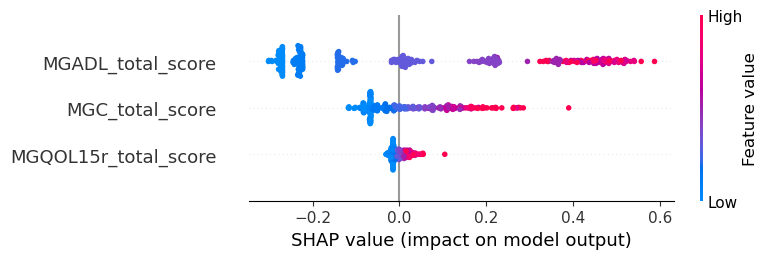

Average SHAP Summary Plot for Logistic Regression


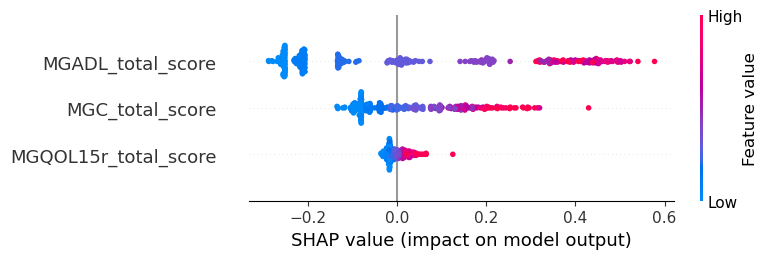

Average SHAP Summary Plot for Random Forest


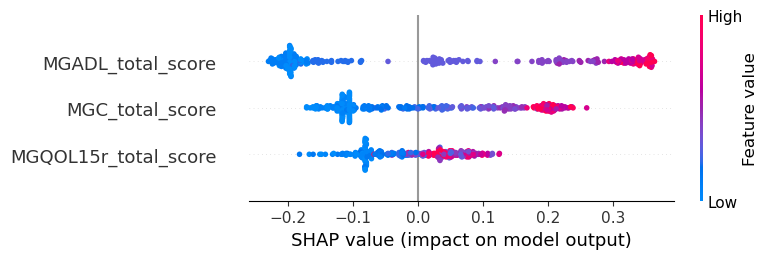

Average SHAP Summary Plot for Naive Bayes


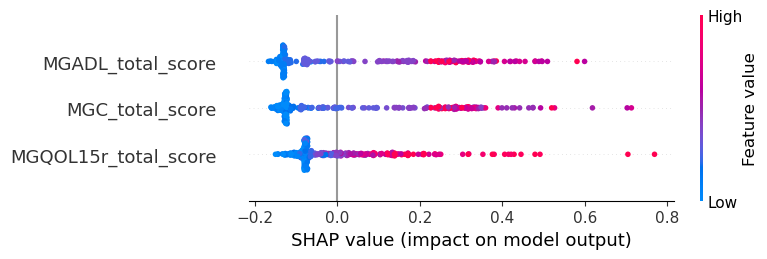

In [16]:
import numpy as np
import shap
import matplotlib.pyplot as plt

shap_values_accumulated = {
    "SVM": [],
    "Logistic Regression": [],
    "Random Forest": [],
    "Naive Bayes": []
}

def calculate_and_accumulate_shap(model, X_train, X_test, model_name):
    """SHAP値を計算し、蓄積"""
    explainer = shap.Explainer(model.predict_proba, X_train)
    shap_values = explainer(X_test)
    shap_values_accumulated[model_name].append(shap_values.values[:, :, 0])
    return shap_values.data

def plot_average_shap(shap_values_list, feature_data, model_name, feature_names=None):
    """蓄積された SHAP 値の平均をプロット"""
    shap_values_mean = np.mean(np.array(shap_values_list), axis=0)
    print(f"Average SHAP Summary Plot for {model_name}")
    shap.summary_plot(shap_values_mean, feature_data, feature_names=feature_names)
    plt.show()

feature_data = None
for model_name, model in tuned_models.items():
    if hasattr(model, "predict_proba"):
        feature_data = calculate_and_accumulate_shap(model, X_train, X_test, model_name)

for model_name, shap_values_list in shap_values_accumulated.items():
    if shap_values_list:
        plot_average_shap(
            shap_values_list,
            feature_data,
            model_name,
            feature_names=X_train.columns if hasattr(X_train, 'columns') else None
        )

In [9]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, matthews_corrcoef, roc_auc_score

# Evaluation of all models
for name, model in tuned_models.items():
    # Get the predicted classes for the test data
    y_pred = model.predict(X_test)

    # Get the predicted probabilities for the positive class
    predicted_probs = predicted_probs_list[name]

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=1)
    f1 = f1_score(y_test, y_pred, zero_division=1)
    mcc = matthews_corrcoef(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, predicted_probs)

    # Print evaluation metrics
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(f"Matthews Correlation Coefficient: {mcc:.2f}")
    print(f"ROC AUC: {roc_auc:.2f}")
    print("-" * 30)

Model: SVM
Accuracy: 0.83
Precision: 0.82
F1 Score: 0.86
Matthews Correlation Coefficient: 0.67
ROC AUC: 0.92
------------------------------
Model: Logistic Regression
Accuracy: 0.83
Precision: 0.81
F1 Score: 0.86
Matthews Correlation Coefficient: 0.67
ROC AUC: 0.92
------------------------------
Model: Random Forest
Accuracy: 0.83
Precision: 0.82
F1 Score: 0.85
Matthews Correlation Coefficient: 0.65
ROC AUC: 0.92
------------------------------
Model: Naive Bayes
Accuracy: 0.83
Precision: 0.81
F1 Score: 0.85
Matthews Correlation Coefficient: 0.65
ROC AUC: 0.91
------------------------------


In [10]:
def optimal_cutoff(y_true, y_pred_probs):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
    J = tpr - fpr
    ix = np.argmax(J)
    return thresholds[ix]

Model: SVM
Training Metrics with Optimal Cut-off:
  Accuracy: 0.86
  Precision: 0.91
  F1 Score: 0.88
  Matthews Correlation Coefficient (MCC): 0.72
------------------------------
Test Metrics with Optimal Cut-off:
  Accuracy: 0.82
  Precision: 0.84
  F1 Score: 0.84
  Matthews Correlation Coefficient (MCC): 0.64


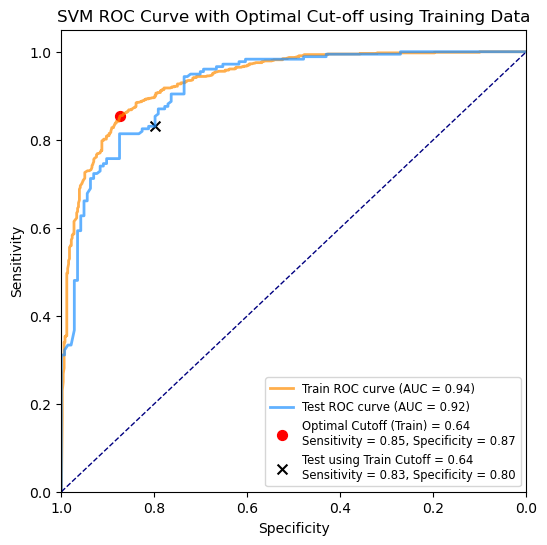

Model: Logistic Regression
Training Metrics with Optimal Cut-off:
  Accuracy: 0.86
  Precision: 0.90
  F1 Score: 0.88
  Matthews Correlation Coefficient (MCC): 0.72
------------------------------
Test Metrics with Optimal Cut-off:
  Accuracy: 0.82
  Precision: 0.84
  F1 Score: 0.84
  Matthews Correlation Coefficient (MCC): 0.63


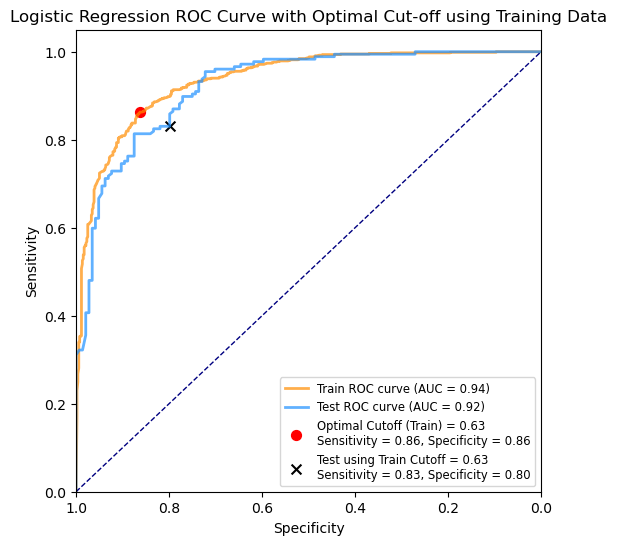

Model: Random Forest
Training Metrics with Optimal Cut-off:
  Accuracy: 0.89
  Precision: 0.92
  F1 Score: 0.90
  Matthews Correlation Coefficient (MCC): 0.77
------------------------------
Test Metrics with Optimal Cut-off:
  Accuracy: 0.82
  Precision: 0.84
  F1 Score: 0.84
  Matthews Correlation Coefficient (MCC): 0.64


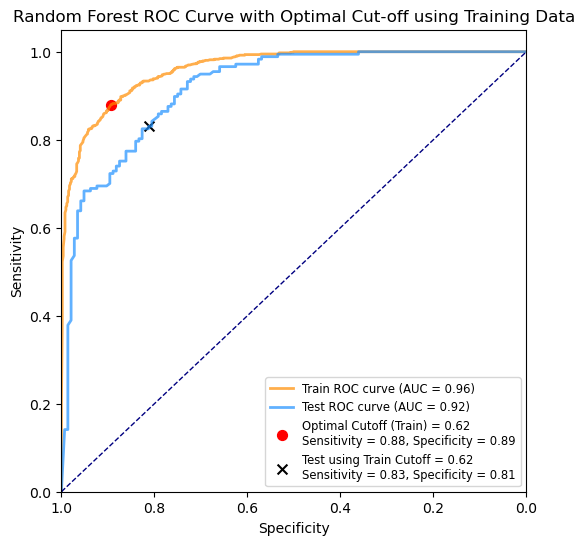

Model: Naive Bayes
Training Metrics with Optimal Cut-off:
  Accuracy: 0.86
  Precision: 0.88
  F1 Score: 0.88
  Matthews Correlation Coefficient (MCC): 0.70
------------------------------
Test Metrics with Optimal Cut-off:
  Accuracy: 0.83
  Precision: 0.84
  F1 Score: 0.85
  Matthews Correlation Coefficient (MCC): 0.67


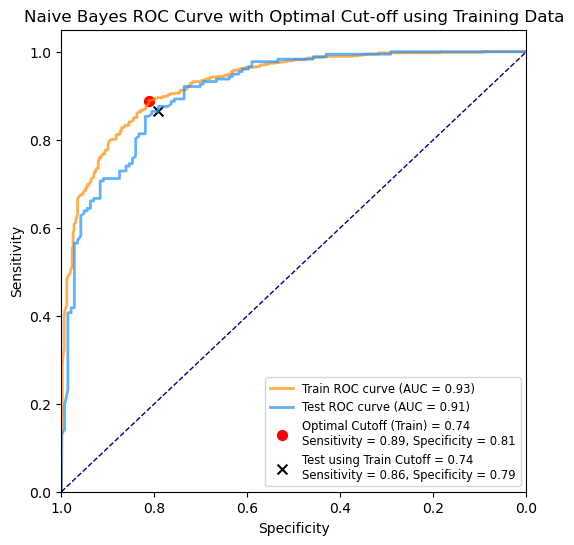

In [11]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, matthews_corrcoef, roc_auc_score

# Evaluation of all models and plotting ROC curve with optimal cutoff
for name, model in tuned_models.items():
    # Predict on training and testing data using optimal cutoff
    predicted_probs_train = model.predict_proba(X_train)[:, 1]
    predicted_probs_test = predicted_probs_list[name]

    # Calculate the optimal cutoff value using the training data
    optimal_cutpoint_train = optimal_cutoff(y_train, predicted_probs_train)

    # Threshold-based predictions using the optimal cut-off from training data
    y_pred_train_optimal = (predicted_probs_train >= optimal_cutpoint_train).astype(int)
    y_pred_test_optimal = (predicted_probs_test >= optimal_cutpoint_train).astype(int)

    # Evaluation metrics using optimal cut-off for both train and test data
    accuracy_train = accuracy_score(y_train, y_pred_train_optimal)
    accuracy_test = accuracy_score(y_test, y_pred_test_optimal)
    f1_train = f1_score(y_train, y_pred_train_optimal, zero_division=1)
    f1_test = f1_score(y_test, y_pred_test_optimal, zero_division=1)
    precision_train = precision_score(y_train, y_pred_train_optimal, zero_division=1)
    precision_test = precision_score(y_test, y_pred_test_optimal, zero_division=1)
    mcc_train = matthews_corrcoef(y_train, y_pred_train_optimal)
    mcc_test = matthews_corrcoef(y_test, y_pred_test_optimal)
    
    # Print out evaluation metrics for both train and test using the optimal cutoff
    print(f"Model: {name}")
    print(f"Training Metrics with Optimal Cut-off:")
    print(f"  Accuracy: {accuracy_train:.2f}")
    print(f"  Precision: {precision_train:.2f}")
    print(f"  F1 Score: {f1_train:.2f}")
    print(f"  Matthews Correlation Coefficient (MCC): {mcc_train:.2f}")
    print("-" * 30)
    print(f"Test Metrics with Optimal Cut-off:")
    print(f"  Accuracy: {accuracy_test:.2f}")
    print(f"  Precision: {precision_test:.2f}")
    print(f"  F1 Score: {f1_test:.2f}")
    print(f"  Matthews Correlation Coefficient (MCC): {mcc_test:.2f}")
    print("=" * 50)

    # Plot ROC curve with optimal cut-off for each model on both training and test data
    fpr_train, tpr_train, thresholds_train = roc_curve(y_train, predicted_probs_train)
    fpr_test, tpr_test, thresholds_test = roc_curve(y_test, predicted_probs_test)
    roc_auc_train = auc(fpr_train, tpr_train)
    roc_auc_test = auc(fpr_test, tpr_test)

    optimal_index_train = np.argmin(np.abs(thresholds_train - optimal_cutpoint_train))
    optimal_index_test = np.argmin(np.abs(thresholds_test - optimal_cutpoint_train))

    plt.figure(figsize=(6, 6), dpi=100)

    plt.plot(1 - fpr_train, tpr_train, color="darkorange", lw=2, label=f"Train ROC curve (AUC = {roc_auc_train:.2f})", alpha=0.7)
    plt.plot(1 - fpr_test, tpr_test, color="dodgerblue", lw=2, linestyle='-', label=f"Test ROC curve (AUC = {roc_auc_test:.2f})", alpha=0.7)

    # Mark the optimal cutoff points
    plt.scatter(1 - fpr_train[optimal_index_train], tpr_train[optimal_index_train], color="red", marker="o", s=50, label=f"Optimal Cutoff (Train) = {optimal_cutpoint_train:.2f}\nSensitivity = {tpr_train[optimal_index_train]:.2f}, Specificity = {1 - fpr_train[optimal_index_train]:.2f}")
    plt.scatter(1 - fpr_test[optimal_index_test], tpr_test[optimal_index_test], color="black", marker="x", s=50, label=f"Test using Train Cutoff = {optimal_cutpoint_train:.2f}\nSensitivity = {tpr_test[optimal_index_test]:.2f}, Specificity = {1 - fpr_test[optimal_index_test]:.2f}")

    # Plot diagonal line representing random guess
    plt.plot([1, 0], [0, 1], color="navy", lw=1, linestyle="--")

    # Plot settings
    plt.xlim([1.0, 0.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("Specificity")
    plt.ylabel("Sensitivity")
    plt.title(f"{name} ROC Curve with Optimal Cut-off using Training Data")
    plt.legend(loc="lower right", fontsize='small', fancybox=True)
    
    # Show or save figure as needed
    plt.show()


In [12]:
import pandas as pd

# Read the CSV file with a different encoding (try 'latin1')
validation_df_path = "./data/df_3rd.csv"
try:
    validation_df = pd.read_csv(validation_df_path, encoding='latin1')
except UnicodeDecodeError:
    # If 'latin1' doesn't work, try other encodings like 'ISO-8859-1' or 'cp1252'
    validation_df = pd.read_csv(validation_df_path, encoding='ISO-8859-1')

In [13]:
df_names = ["MMorbetter", "MGC_total_score", "MGADL_total_score", "MGQOL15_total_score"]

validation_df = validation_df[df_names]
validation_df = validation_df.rename(columns={"MGQOL15_total_score": "MGQOL15r_total_score"})

In [14]:
X_validation = validation_df[["MGC_total_score", "MGADL_total_score", "MGQOL15r_total_score"]]
y_validation = validation_df["MMorbetter"]

for name, model in tuned_models.items():
    predicted_probs_validation = model.predict_proba(X_validation)[:, 1]

    optimal_cutpoint_train = optimal_cutoff(y_train, model.predict_proba(X_train)[:, 1])

    y_pred_validation_optimal = (predicted_probs_validation >= optimal_cutpoint_train).astype(int)

    accuracy_validation = accuracy_score(y_validation, y_pred_validation_optimal)
    precision_validation = precision_score(y_validation, y_pred_validation_optimal, zero_division=1)
    f1_validation = f1_score(y_validation, y_pred_validation_optimal, zero_division=1)
    mcc_validation = matthews_corrcoef(y_validation, y_pred_validation_optimal)
    roc_auc_validation = roc_auc_score(y_validation, predicted_probs_validation)

    print(f"Model: {name}")
    print(f"Validation Metrics with Optimal Cut-off:")
    print(f"  Accuracy: {accuracy_validation:.2f}")
    print(f"  Precision: {precision_validation:.2f}")
    print(f"  F1 Score: {f1_validation:.2f}")
    print(f"  Matthews Correlation Coefficient (MCC): {mcc_validation:.2f}")
    print(f"  ROC AUC: {roc_auc_validation:.2f}")
    print("=" * 50)

Model: SVM
Validation Metrics with Optimal Cut-off:
  Accuracy: 0.89
  Precision: 0.88
  F1 Score: 0.91
  Matthews Correlation Coefficient (MCC): 0.76
  ROC AUC: 0.95
Model: Logistic Regression
Validation Metrics with Optimal Cut-off:
  Accuracy: 0.88
  Precision: 0.88
  F1 Score: 0.91
  Matthews Correlation Coefficient (MCC): 0.75
  ROC AUC: 0.95
Model: Random Forest
Validation Metrics with Optimal Cut-off:
  Accuracy: 0.87
  Precision: 0.86
  F1 Score: 0.90
  Matthews Correlation Coefficient (MCC): 0.72
  ROC AUC: 0.93
Model: Naive Bayes
Validation Metrics with Optimal Cut-off:
  Accuracy: 0.86
  Precision: 0.88
  F1 Score: 0.88
  Matthews Correlation Coefficient (MCC): 0.69
  ROC AUC: 0.93


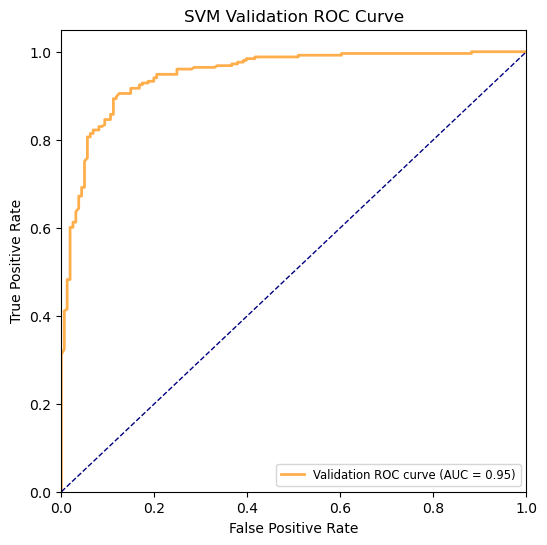

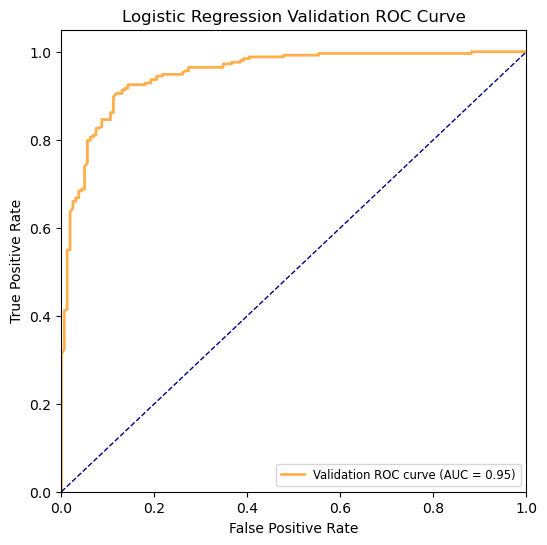

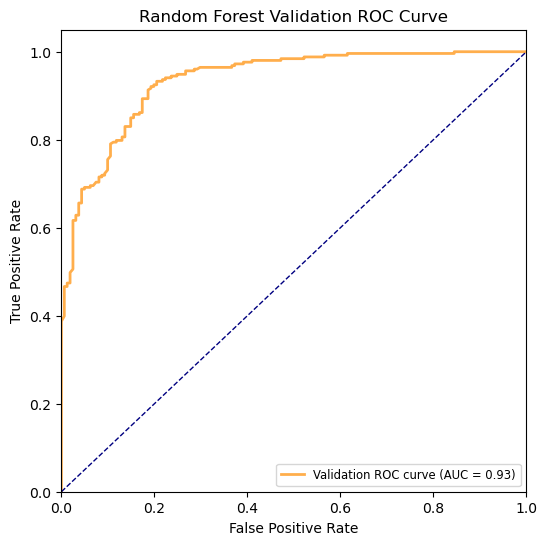

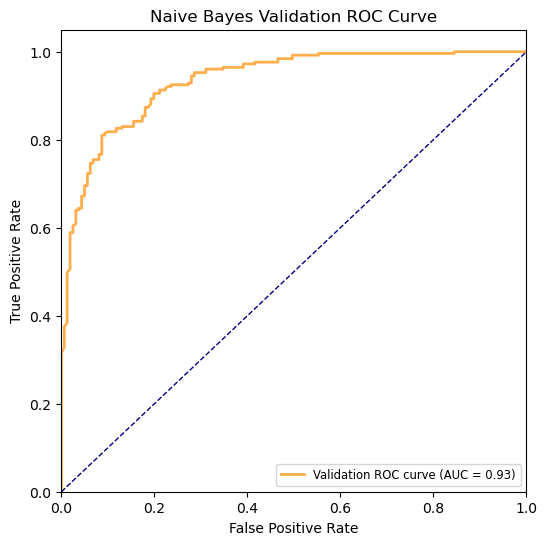

In [15]:
# Plot ROC curve for validation data for each model
for name, model in tuned_models.items():
    # Calculate predicted probabilities for validation data
    predicted_probs_validation = model.predict_proba(X_validation)[:, 1]

    # Calculate ROC curve and AUC for validation data
    fpr_validation, tpr_validation, thresholds_validation = roc_curve(y_validation, predicted_probs_validation)
    roc_auc_validation = auc(fpr_validation, tpr_validation)

    # Plot ROC curve for validation data
    plt.figure(figsize=(6, 6), dpi=100)
    plt.plot(fpr_validation, tpr_validation, color="darkorange", lw=2, label=f"Validation ROC curve (AUC = {roc_auc_validation:.2f})", alpha=0.7)

    # Plot diagonal line representing random guess
    plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")

    # Plot settings
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} Validation ROC Curve")
    plt.legend(loc="lower right", fontsize='small', fancybox=True)

    # Show the ROC curve plot
    plt.show()